### Notebook 8: Stations, takeoff angles, and radial/transverse projections

We compute stacks for a number of stations.  It will be interesting to compare the stacks obtained at stations in particular directions, or with particular takeoff angles and radiation coefficients.  Here we 
- load the information about these stations
- compute takeoff angles and station azimuths
- compute "effective locations" to match the takeoff for particular depths and
- project the seismograms to the radian and tranverse components

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import os,sys
sys.path.append(os.path.join(os.environ['PYFILES']))
import LFEAnalysis as lfeanalysis
lfeanalysis.reload_all(lfeanalysis)

### 1. Load and prepare the data

This reads in the data and does some grouping by time.

In [2]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfeanalyse(fnum=156,catalog='Bostock',region='Cascadia')

# and read the relevant detections
lf.read_detection_info()

# load the data
lf.read_data()

# normalise the seismograms
lf.normalize_data(single_norm=False)

# we may first need to discard any LFE intervals that contain NaNs, 
lf.discard_data_with_nans()

# and bandpass filter
lf.filter_data(flm=[1,10])

### 2. Stack

In [3]:
# stack for each group
lf.stack_by_group()

# and pick arrival times
lf.pick_stacks(minsnr=10)

### 3. Read in information about the station locations

The function read_station_locations reads information about the station locations from an xml inventory.  That inventory is assumed to be in the directory for the family of interest, within lf.data_directory/lf.region/FamilyXXX.

In [4]:
lfeanalysis.reload_all(lfeanalysis)
lf=lfeanalysis.lfeanalyse(fnum=156,lfi=lf)

print(lf.data_directory)
print(lf.directory())

# read the station locations
lf.read_station_locations()

# this provides a dictionary of the station locations
print('Station locations are in the dictionary lf.statloc, with keys\n',lf.statloc.keys())
ky=list(lf.statloc.keys())[0]

fmt='\nStation {:s} is a longitude {:0.2f}, latitude {:0.2f}'
print(fmt.format(ky,lf.statloc[ky][0],lf.statloc[ky][1]))

/Users/jessicahawthorne/DATA/LFEAnalysis
/Users/jessicahawthorne/DATA/LFEAnalysis/Cascadia/Family156
Reading station info from directory /Users/jessicahawthorne/DATA/LFEAnalysis/Cascadia/Family156
Station locations are in the dictionary lf.statloc, with keys
 dict_keys(['BPCB', 'KHVB', 'MGCB', 'SHDB', 'SHVB', 'LZB', 'NLLB', 'PGC', 'YOUB', 'B926', 'KLNB', 'SILB', 'SSIB', 'TWKB'])

Station BPCB is a longitude -123.70, latitude 48.92


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/core/inventory/network.py:321: UserWarning: Found more than one matching channel metadata. Returning first.
  warnings.warn(msg)


### 4. Compute the relative station locations, in terms of distance from the LFE family

The function 'relative_station_locations' uses some of obspy's function to get the distances and azimuths from the LFE to the station.

In [5]:
# note the LFE location
print('LFE longitude, latitude, depth (in km):',lf.floc)

# note the compute the station location relative to the LFE family we're working with
lf.relative_station_locations()

print('\nThe station distances and azimuths are saved in statdst and stataz, respectively')

print('\nStation {:s} is located {:0.0f} km from the LFE, horizontally'.format(ky,lf.statdst[ky]))
print('It is at azimuth {:0.0f} from the LFE'.format(lf.stataz[ky]))

# alternatively the relative station locations in [E,N] components (km) are in lf.statxy
print('We can also calculate an E-N location, projecting to a planar system: ')
print('\nRelative E-N station location of {:s} (km):'.format(ky),lf.statxy[ky])

LFE longitude, latitude, depth (in km): [-123.6187   48.5193   36.96  ]

The station distances and azimuths are saved in statdst and stataz, respectively

Station BPCB is located 45 km from the LFE, horizontally
It is at azimuth 352 from the LFE
We can also calculate an E-N location, projecting to a planar system: 

Relative E-N station location of BPCB (km): [-6.28778736 44.96344799]


### 5. Compute the takeoff angles

The computation above gives the distance and azimuth to the stations, but we may wish to know the direction of a propagating seismic wave as it leaves the LFE and heads towards the station.  

We'll compute this using obspy's implementation of TauP.  The function find_takeoff_angles computes the arrival times of s and S waves for the stations of interest. The takeoff angles, phases, and arrival times are saved in lf.takeoff_angles, lf.phases, and lf.arrival_times.

In [6]:
# compute the takeoff angle to each station, using an iasp91 velocity model
lf.find_takeoff_angles(velmodel='iasp91')

print('The takeoff angles of the first-arriving seismic waves are in lf.takeoff_angles')
print(lf.takeoff_angles)

print('\nMost of these arrivals correspond to upgoing s waves, as noted in lf.phases: ')
print(lf.phases)

print('\nThe arrival times are noted in lf.arrival_times: ')
print(lf.arrival_times)

print('\nAnd the full output of TauP\'s arrival computation is in lf.arrivals: ')
print(lf.arrivals)

The takeoff angles of the first-arriving seismic waves are in lf.takeoff_angles
{'BPCB': array([108.89615551]), 'KHVB': array([156.37597562]), 'MGCB': array([154.97581136]), 'SHDB': array([127.27220845]), 'SHVB': array([169.63165049]), 'LZB': array([146.34133042]), 'NLLB': array([92.73627811]), 'PGC': array([145.22009458]), 'YOUB': array([95.94633628]), 'B926': array([103.61462531]), 'KLNB': array([150.00866931]), 'SILB': array([133.51935859]), 'SSIB': array([126.67753604]), 'TWKB': array([149.75083104])}

Most of these arrivals correspond to upgoing s waves, as noted in lf.phases: 
{'BPCB': array(['s'], dtype='<U1'), 'KHVB': array(['s'], dtype='<U1'), 'MGCB': array(['s'], dtype='<U1'), 'SHDB': array(['s'], dtype='<U1'), 'SHVB': array(['s'], dtype='<U1'), 'LZB': array(['s'], dtype='<U1'), 'NLLB': array(['s'], dtype='<U1'), 'PGC': array(['s'], dtype='<U1'), 'YOUB': array(['s'], dtype='<U1'), 'B926': array(['s'], dtype='<U1'), 'KLNB': array(['s'], dtype='<U1'), 'SILB': array(['s'], dtype

### 6. Note modified distances, given a reference depth

We may wish to compare signals from LFEs that occur at a range of depths.  And we may wish to do that comparison on a map rather than a stereonet, as it's more intuitive.  So the function find_takeoff_angle also does one further computation.  It finds the station distances that would correspond to the actual takeoff angles _if_ the LFE were at a difference reference depth. This calculation only considers the upgoing s wave. 

In [7]:
# compute the takeoff angle to each station, using an iasp91 velocity model
# and interpolate to the effective distances for a 30-km-deep LFE
lf.find_takeoff_angles(velmodel='iasp91',refdepth=30)

print('The modified distances are saved in lf.statdstm: ',lf.statdstm)

print('\nAnd the modified x-y locations, assuming a planar surface, are saved in lf.statdstm: ',lf.statxym)

The modified distances are saved in lf.statdstm:  {'BPCB': np.float64(60.77113182640016), 'KHVB': np.float64(12.066221424576066), 'MGCB': np.float64(12.857646244525641), 'SHDB': np.float64(33.40669674822868), 'SHVB': np.float64(5.098340412672374), 'LZB': np.float64(18.091615399412408), 'NLLB': np.float64(199.0), 'PGC': np.float64(18.827051468571675), 'YOUB': np.float64(128.94235699645716), 'B926': np.float64(75.90695356971543), 'KLNB': np.float64(15.785441055485467), 'SILB': np.float64(27.587236148641704), 'SSIB': np.float64(34.015010438898344), 'TWKB': np.float64(15.941800475765476)}

And the modified x-y locations, assuming a planar surface, are saved in lf.statdstm:  {'BPCB': array([-8.41647147, 60.1854922 ]), 'KHVB': array([10.83364918,  5.31279069]), 'MGCB': array([-4.42095162, 12.07370091]), 'SHDB': array([-1.37379303, 33.37843736]), 'SHVB': array([-1.21210298, -4.95215926]), 'LZB': array([-14.9343344,  10.2113762]), 'NLLB': array([-64.3370803 , 188.31287821]), 'PGC': array([12.1

### 7. Examine arriving phases  

The grid search of takeoff angles can also be useful to examine the arrivals we expect at a range of distances. 

The distance that corresponds to a 45-degree upward takeoff is 54 km
The distance that corresponds to the closest downgoing wave is 27 km


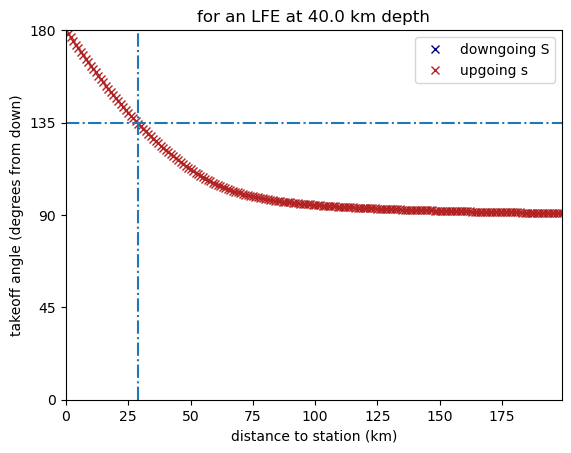

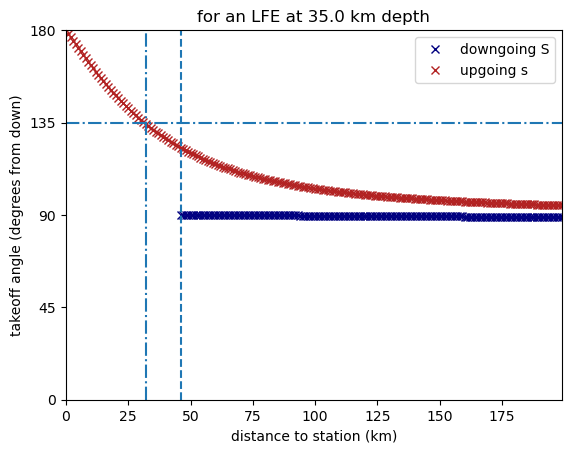

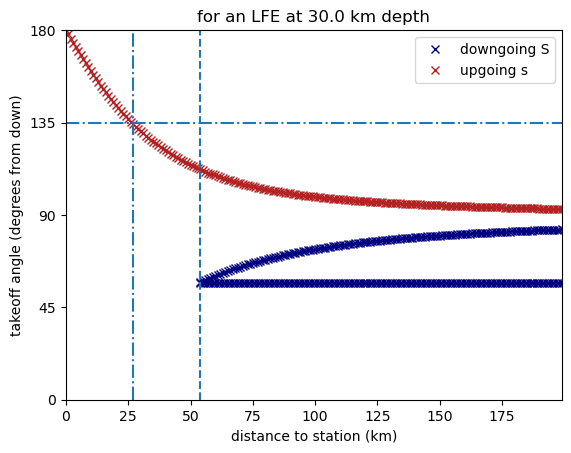

In [8]:
# note that the takeoff pattern can change for LFEs of various depths 
lf.grid_takeoff_angles(plot=True,refdepth=40.);
lf.grid_takeoff_angles(plot=True,refdepth=35.);
lf.grid_takeoff_angles(plot=True,refdepth=30.);

# the takeoff angles for the upgoing s waves are saved in lf.tkang_litS
# the takeoff angles for the downgoing S waves are saved in lf.tkang_bigS
# and the distances used for the computations are saved in lf.dst_grid

# two other reference distances and takeoff angles may be useful
print('The distance that corresponds to a 45-degree upward takeoff is {:0.0f} km'.format(lf.ref_distances[0]))
print('The distance that corresponds to the closest downgoing wave is {:0.0f} km'.format(lf.ref_distances[1]))
 

### 8. Project to the radial and transverse component

Now that we know azimuth from the source to receiver, we can move the horizontal seismograms from the E-N components to the R-T components.  This will normally be done by certain sections of the scaling code, but to check that it's correct, we can do it directly here with the function lf.project_waveforms.

In [9]:
# let's start with the seismograms from B926
# these have the E, N, and Z components of motion
stn='B926'
st=lf.totstk.select(station=stn).copy()
print(st)

3 Trace(s) in Stream:
.B926..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples
.B926..N | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples
.B926..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples


In [10]:
# grab the azimuth from the LFE to this station
azm=lf.stataz[stn]
print('Station is at azimuth {:0.0f}'.format(azm))

Station is at azimuth 312


In [11]:
# project the waveforms to consider this azimuth
strot,datarot=lf.project_waveforms(st,y_azimuths=[azm])
print(strot)

# the "X" component here is the transverse component, with positive to the right of propagation
# the "Y" is the radial component, with positive as partly away

2 Trace(s) in Stream:
.B926..X_312 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples
.B926..Y_312 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples


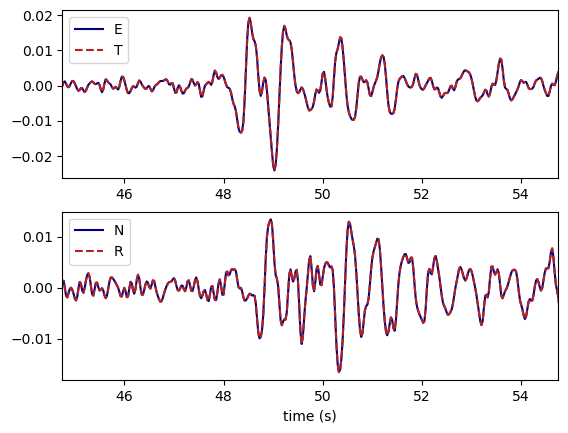

In [12]:
# to check, let's arbitrarily fix the azimuth to 0
# then the north component should be the radial, and the east component should be the transverse
strot,datarot=lf.project_waveforms(st,y_azimuths=[0])
tref=st[0].stats.starttime+st[0].stats.t0

# grab the times and the data
times=st[0].times()
tref=st[0].stats.t0
dataE=st.select(channel='E')[0].data
dataT=strot.select(channel='X*')[0].data
dataN=st.select(channel='N')[0].data
dataR=strot.select(channel='Y*')[0].data

p=plt.subplot(2,1,1)
p.plot(times,dataE,label='E',color='navy')
p.plot(times,dataT,label='T',color='firebrick',linestyle='--')
p.set_xlim([tref-3,tref+7])
p.legend()

p=plt.subplot(2,1,2)
p.plot(times,dataN,label='N',color='navy')
p.plot(times,dataR,label='R',color='firebrick',linestyle='--')
p.set_xlim([tref-3,tref+7])
p.legend();

p.set_xlabel('time (s)');

In some cases, we'll also have 2-D arrays of seismograms to rotate: the bootstrapped stacks, for instance.  We can obtain these rotations by specifying the data parameter in lf.project_waveforms.

In [13]:
# say we want to project the best stack as well as the bootstrapped stacks
strot,datarot=lf.project_waveforms(lf.totstk,y_azimuths=[azm],stns=[stn],data=lf.totstkb)

# by specifying the station, we just get the results for that station
print('The rotated total stack is in strot:',strot)

# and the rotated data are also just for this stack
print('\nThe rotated bootstrap stacks are in datarot, with keys ',datarot.keys())
print('The bootstrapped transverse components have shape ',datarot['.'.join(['B926','X'])].shape)

The rotated total stack is in strot: 2 Trace(s) in Stream:
.B926..X_312 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples
.B926..Y_312 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples

The rotated bootstrap stacks are in datarot, with keys  dict_keys(['B926.X', 'B926.Y'])
The bootstrapped transverse components have shape  (3200, 10)


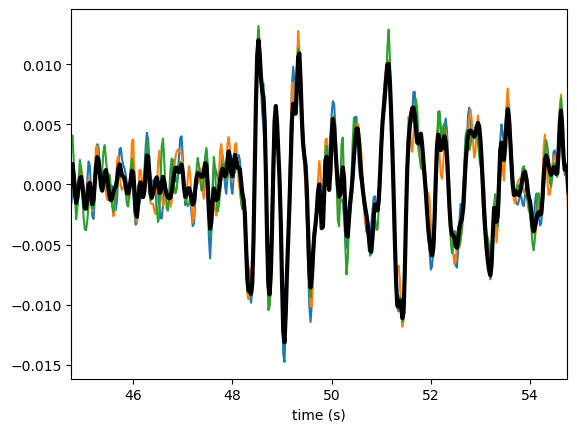

In [14]:
# go ahead and plot some of these
plt.plot(times,datarot['.'.join(['B926','X'])][:,0:3])
dataT=strot.select(channel='X*')[0].data
plt.plot(times,dataT,color='k',linewidth=3)
plt.xlim([tref-3,tref+7])
plt.xlabel('time (s)');

### 8. Calculate radiation coefficients

We can also use the computed takeoff angles and azimuths to calculate the radiation coefficients we expect for shear slip on the fault and for fault opening.

The radiation coefficient calculation uses the function lf.calc_radiation coefficients.  This function uses the code in radpatterns, which uses standard equations for expected coefficients of the P, SH, and SV waves.  The code radpatterns is also available as a separate package at https://github.com/jchawthorne/RadPatterns.  

For these calculations, we must specify a strike, dip, and rake of the fault.  



In [65]:
# first calculate the radiation coefficients for shear and opening motion on the fault
lf.calc_radiation_coefficients(strike=315,dip=20,rake=90)

print('The radiation coefficients are saved in dictionaries lf.radcoeff_shear and lf.radcoeff_open')

The radiation coefficients are saved in dictionaries lf.radcoeff_shear and lf.radcoeff_open


We may be interesting in the ratio of the radiation coefficients for the opening and shear components, as these determine how the waveforms could change if there is significant fault zone dilation.  

For these computations, we have to make some assumption about which arrival dominates the seismic record.  We have two possible approaches: 'first', which just considers the first-arriving seismic wave, and 'weighted', which sums the radiation coefficients according to the amount of time each signal spends in the analysis window.

In [66]:
# then calculate the ratios of the opening to the shear radiation coefficients
lf.calc_radcoeff_ratios(phase='weighted')

print('The ratios of the radiation coefficients are saved in dictionaries lf.radcoeff_ratios')

The ratios of the radiation coefficients are saved in dictionaries lf.radcoeff_ratios


In [67]:
print('The ratio of the opening to shear radiation coefficients are ');
print('{:10s}{:10s}{:10s}'.format('','SH','SV'))
for ky in lf.radcoeff_ratios['SH'].keys():
    print('{:10s}{:10.2f}{:10.2f}'.format(ky,lf.radcoeff_ratios['SH'][ky],lf.radcoeff_ratios['SV'][ky]))

The ratio of the opening to shear radiation coefficients are 
          SH        SV        
BPCB           -0.56     -8.53
KHVB           -0.72      0.17
MGCB           -0.77      0.98
SHDB           -0.64      2.92
SHVB           -0.91     -1.92
LZB            -0.89      3.40
NLLB           -0.42     -1.22
PGC            -0.66      0.57
YOUB           -1.16      1.45
B926           -0.96      2.00
KLNB           -0.70      0.53
SILB           -0.63      1.48
SSIB           -0.59      2.37
TWKB           -0.79      1.78
